<div style="text-align:center;">

<h1>Probabilistic Programming</h1>
<h3 style="color:gray;">Spring 2026</h3>

<hr style="width:60%; margin: 20px auto;">

<p><strong>Exam Submission</strong></p>
<p><b>Course code:</b> BSPRPRO1KU</p>

<br>

<p>
<strong>Aniela Marta Ciecierska</strong><br>
<a href="mailto:anci@itu.dk">anci@itu.dk</a>
</p>

<p>
<strong>Jakub Piotr Gasior</strong><br>
<a href="mailto:jaga@itu.dk">jaga@itu.dk</a>
</p>

<p>
<strong>Zofia Brodewicz</strong><br>
<a href="mailto:zobr@itu.dk">zobr@itu.dk</a>
</p>

</div>

<div style="text-align:center; margin:30px auto; max-width:900px;">

<h2>
An analysis of the propensity of Large Language Models to generate programs with software vulnerabilities
</h2>

</div>

# Introduction

# Data Loading and Cleaning

Explanations on how data is loaded and cleaned.

In [2]:
# imports
import numpy as np 
import pandas as pd
import arviz as az
import pymc as pm
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("dataset.csv")

# EDA (Exploratory Data Analysis)

Before building any models, we conduct an exploratory analysis of the dataset to understand the structure and distribution of the data. This includes examining the distribution of vulnerabilities across LLMs, the frequency of different vulnerability types, and the relationships between key variables such as lines of code and cyclomatic complexity.

#### 1. How does the data look?

In [3]:
df.head()

,c_file_name,category,error_type,llm_name,num_parameters,num_lines,cyclomatic_complexity
0,6109.c,VULNERABLE,dereference failure: NULL pointer,llama2,13.0,63,2.333
1,24107.c,VULNERABLE,dereference failure: NULL pointer,gemini_pro,NaN,55,1.667
2,74967.c,VULNERABLE,arithmetic overflow on sub,gpt35,NaN,107,6.000
3,15468.c,VULNERABLE,array bounds violated: upper bound,llama2,13.0,56,9.000
4,12779.c,VULNERABLE,dereference failure: invalid pointer,falcon,180.0,74,6.000


#### 2. What is the size of the dataset?

In [8]:
df.shape

(1766, 7)

#### 3. Overwiev of the dataset's structure (data type, missing values and unique values)

In [9]:
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "missing_values": df.isna().sum().values,
    "unique_values": df.nunique().values
})

summary

,column,dtype,missing_values,unique_values
0,c_file_name,object,0,1728
1,category,object,0,4
2,error_type,object,253,29
3,llm_name,object,0,9
4,num_parameters,float64,927,4
5,num_lines,int64,0,170
6,cyclomatic_complexity,float64,0,175


#### 4. which LLMs tend to generate more problematic code?

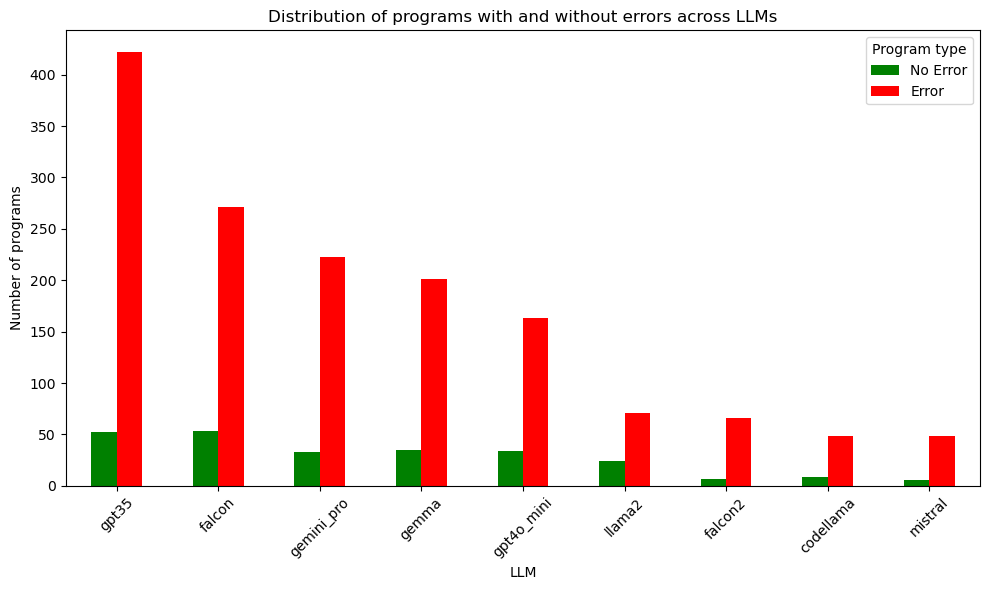

In [18]:
grouped = grouped[["No Error", "Error"]]

grouped.plot(
    kind="bar",
    figsize=(10, 6),
    color=["green", "red"]
)

plt.title("Distribution of programs with and without errors across LLMs")
plt.xlabel("LLM")
plt.ylabel("Number of programs")
plt.xticks(rotation=45)
plt.legend(title="Program type")

plt.tight_layout()
plt.show()

#### 5. Error types in the data 

In [27]:
df["error_type"].value_counts()

dereference failure: NULL pointer                                   569
buffer overflow on scanf                                            444
dereference failure: invalid pointer                                136
dereference failure: array bounds violated                           56
array bounds violated: upper bound                                   49
dereference failure: forgotten memory                                45
array bounds violated: lower bound                                   41
arithmetic overflow on sub                                           36
arithmetic overflow on add                                           27
arithmetic overflow on mul                                           20
arithmetic overflow on floating-point ieee_mul                       18
buffer overflow on fscanf                                            13
VLA array size in bytes overflows address space size                  9
buffer overflow on sscanf                                       

#### 6. Error rate across different LLMs

In [28]:
df_corr = df.copy()

df_corr["has_error"] = df_corr["error_type"].notna()

error_rate = (
    df_corr.groupby("llm_name")["has_error"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "total_programs",
        "sum": "programs_with_error",
        "mean": "error_rate"
    })
    .sort_values("error_rate", ascending=False)
)

error_rate

,total_programs,programs_with_error,error_rate
llm_name,,,
falcon2,73,66,0.904110
gpt35,474,422,0.890295
mistral,54,48,0.888889
gemini_pro,256,223,0.871094
gemma,236,201,0.851695
codellama,57,48,0.842105
falcon,324,271,0.836420
gpt4o_mini,197,163,0.827411
llama2,95,71,0.747368


#### 7. Distribution of errors across LLMs

In [30]:
llm_error_table = pd.crosstab(
    df["llm_name"],
    df["error_type"]
)

llm_error_table

error_type,VLA array size in bytes overflows address space size,arithmetic overflow on add,arithmetic overflow on div,arithmetic overflow on floating-point ieee_add,arithmetic overflow on floating-point ieee_div,arithmetic overflow on floating-point ieee_mul,arithmetic overflow on floating-point ieee_sub,arithmetic overflow on mul,arithmetic overflow on shl,arithmetic overflow on sub,...,dereference failure: accessed expired variable pointer,dereference failure: array bounds violated,dereference failure: forgotten memory,dereference failure: invalid pointer,dereference failure: invalidated dynamic object,dereference failure: of non-dynamic memory,dereference failure: write access to string constant,division by zero,other,the pointer to a file object must be a valid argument
llm_name,,,,,,,,,,,,,,,,,,,,,
codellama,0,1,0,0,0,0,0,3,0,1,...,0,0,2,4,0,0,0,0,0,1
falcon,2,6,1,1,0,5,0,0,0,3,...,2,10,16,29,0,0,0,2,0,0
falcon2,1,0,0,0,0,1,0,0,0,1,...,0,2,2,9,0,0,0,1,1,1
gemini_pro,1,2,0,0,0,1,0,5,0,7,...,0,7,8,25,1,0,1,0,2,0
gemma,0,4,0,0,2,2,0,4,0,6,...,0,6,3,5,0,1,0,0,0,1
gpt35,5,8,0,2,1,5,1,3,1,14,...,0,19,8,39,1,0,1,2,0,1
gpt4o_mini,0,3,0,0,1,3,0,5,0,4,...,1,5,1,11,0,0,0,1,0,0
llama2,0,3,1,0,1,0,0,0,0,0,...,0,7,5,9,0,0,0,0,0,0
mistral,0,0,0,0,1,1,0,0,0,0,...,0,0,0,5,0,1,0,0,0,0


#### 8. Summary statistics for the three numeric variables in the dataset

In [21]:
summary_numeric = df[numeric_cols].agg([
    "count",
    "mean",
    "std",
    "min",
    "median",
    "max"
]).T

summary_numeric["range"] = summary_numeric["max"] - summary_numeric["min"]
summary_numeric["missing"] = df[numeric_cols].isna().sum()

summary_numeric

,count,mean,std,min,median,max,range,missing
num_parameters,839.0,75.243147,83.167502,7.0,13.0,180.0,173.0,927
num_lines,1766.0,92.314836,38.467550,51.0,82.0,410.0,359.0,0
cyclomatic_complexity,1766.0,4.628059,4.145103,1.0,3.4,68.5,67.5,0


#### 9. Distrubutions of the numeric variables 

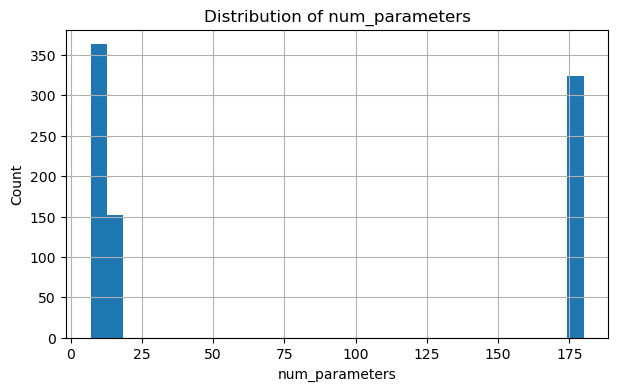

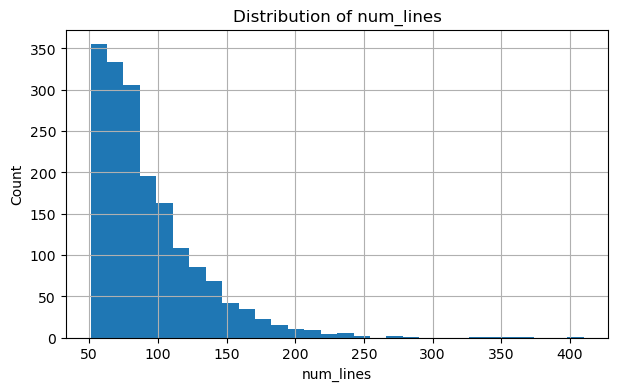

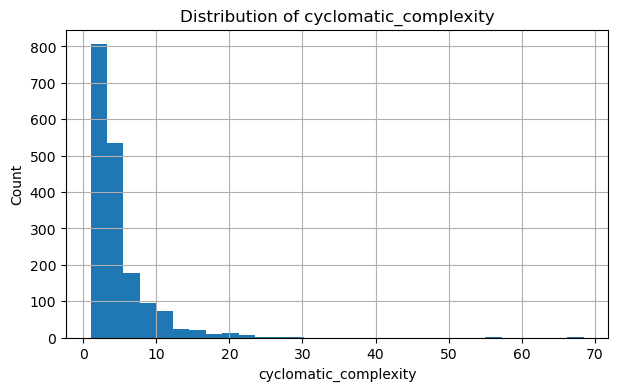

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# Hypothesis 1 

## The LLM llama2 is less likely to produce programs with vulnerabilities than any other LLM in the dataset.

# Hypothesis 2

## Larger values of cyclomatic complexity are associated to larger number of lines of code for all LLMs.

# Hypothesis 3

## A larger number of lines of code increases the probability of observing each vulnerability type.

# Overall Conclusion